In [2]:
import os
import json
import numpy as np

# Define your paths
SOURCE_DIR = './SoT'
OUTPUT_DIR = './spectral_pipeline_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def stage0_ingest_optimized(source_path, output_path):
    """
    PURPOSE: Converts .txt files into a structured JSON with flattened arrays.
    FORMAT: 
        - index: "PBk9"
        - name: "Ivory Black"
        - wavelengths: [350.0, 351.0, ...]
        - reflectance: [2.5, 2.6, ...] (Percentages)
    """
    raw_library = []
    files = [f for f in os.listdir(source_path) if f.endswith('.txt')]
    
    for file_name in files:
        file_path = os.path.join(source_path, file_name)
        try:
            # 1. Parse File Name (e.g. 'PBk9_Ivory_Black.txt')
            clean_filename = file_name.replace('.txt', '')
            parts = clean_filename.split('_', 1) if "_" in clean_filename else ["NA", clean_filename]
            
            # 2. Load Data directly into NumPy
            data = np.loadtxt(file_path)
            
            # 3. Flatten the columns for the JSON
            # We keep them as raw percentages (0-100) and raw wavelengths for now
            raw_library.append({
                "index": parts[0],
                "name": parts[1].replace('_', ' '),
                "wavelengths": data[:, 0].tolist(),
                "reflectance": data[:, 1].tolist()
            })
            
        except Exception as e:
            print(f"⚠️ Error reading {file_name}: {e}")

    # 4. Save to Output folder
    json_path = os.path.join(output_path, "stage0_raw_data.json")
    with open(json_path, 'w') as f:
        json.dump(raw_library, f, indent=4)
    
    print(f"✅ Stage 0 Optimized Complete: {len(raw_library)} pigments saved.")
    return raw_library

# --- RUN ---
stage0_data = stage0_ingest_optimized(SOURCE_DIR, OUTPUT_DIR)


✅ Stage 0 Optimized Complete: 82 pigments saved.


In [3]:
def test_stage0_flattened(data_list):
    sample = next((p for p in data_list if "Ivory Black" in p['name']), None)
    
    if sample:
        w = np.array(sample['wavelengths'])
        r = np.array(sample['reflectance'])
        
        print(f"📊 {sample['name']} Stats:")
        print(f"   Wavelength Range: {w.min()}nm to {w.max()}nm")
        print(f"   Data Points: {len(r)}")
        
        # Verify they are the same length
        assert len(w) == len(r), "Mismatched array lengths!"
        print("✅ Arrays are perfectly aligned.")
    else:
        print("❌ Sample not found.")

test_stage0_flattened(stage0_data)


📊 Ivory Black Stats:
   Wavelength Range: 360.161nm to 939.93nm
   Data Points: 2956
✅ Arrays are perfectly aligned.


In [4]:
import os
import json
import numpy as np
from scipy.interpolate import CubicSpline

# Paths
INPUT_JSON = './spectral_pipeline_output/stage0_raw_data.json'
OUTPUT_DIR = './spectral_pipeline_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def stage1_standardize_data(input_path, output_path):
    """
    PURPOSE: Normalizes raw data to a professional 5nm grid (360-800nm).
    SCIENCE: 
        - Decimal Conversion (0-100% -> 0.0-1.0)
        - Cubic Spline Interpolation (Smooths sensor noise)
        - Clipping (Ensures physical reality: 0 <= R <= 1)
    """
    with open(input_path, 'r') as f:
        raw_data = json.load(f)
    
    standardized_library = []
    
    # Define our target grid: 360 to 800 (inclusive) in 5nm steps = 89 points
    target_w = np.arange(360, 801, 5) 
    
    for p in raw_data:
        try:
            # 1. Load raw arrays
            w_raw = np.array(p['wavelengths'])
            r_raw = np.array(p['reflectance']) / 100.0 # Convert to decimal immediately
            
            # 2. Cubic Spline Interpolation
            # 'bc_type="natural"' ensures the ends of the spectrum don't waggle
            cs = CubicSpline(w_raw, r_raw, bc_type='natural')
            
            # 3. Resample to our 89-point grid
            r_std = cs(target_w)
            
            # 4. Physical Reality Check (Clip values to 0.0 - 1.0)
            r_std = np.clip(r_std, 0.0, 1.0)
            
            standardized_library.append({
                "index": p['index'],
                "name": p['name'],
                "wavelengths": target_w.tolist(),
                "reflectance": r_std.tolist()
            })
            
        except Exception as e:
            print(f"⚠️ Error standardizing {p['name']}: {e}")

    # 5. Save to Stage 1 JSON
    json_path = os.path.join(output_path, "stage1_standardized_data.json")
    with open(json_path, 'w') as f:
        json.dump(standardized_library, f, indent=4)
    
    print(f"✅ Stage 1 Complete: {len(standardized_library)} pigments standardized to 5nm grid.")
    return standardized_library

# --- RUN ---
stage1_data = stage1_standardize_data(INPUT_JSON, OUTPUT_DIR)


✅ Stage 1 Complete: 82 pigments standardized to 5nm grid.


In [5]:
def test_stage1_alignment(data_list):
    # Take any two pigments
    p1 = data_list[0]
    p2 = data_list[-1]
    
    print(f"🧪 Testing Alignment between '{p1['name']}' and '{p2['name']}'")
    
    # 1. Check length (Should be exactly 89)
    assert len(p1['reflectance']) == 89, f"P1 length error: {len(p1['reflectance'])}"
    assert len(p2['reflectance']) == 89, f"P2 length error: {len(p2['reflectance'])}"
    
    # 2. Check Wavelength matching
    assert p1['wavelengths'] == p2['wavelengths'], "Wavelength arrays are not identical!"
    
    # 3. Check Decimal range
    assert np.max(p1['reflectance']) <= 1.0, "Reflectance still in percentage!"
    
    print(f"✅ Stage 1 Test Passed! All pigments aligned to 89 points (360-800nm).")

test_stage1_alignment(stage1_data)


🧪 Testing Alignment between 'Methilene Blue' and 'sepia'
✅ Stage 1 Test Passed! All pigments aligned to 89 points (360-800nm).


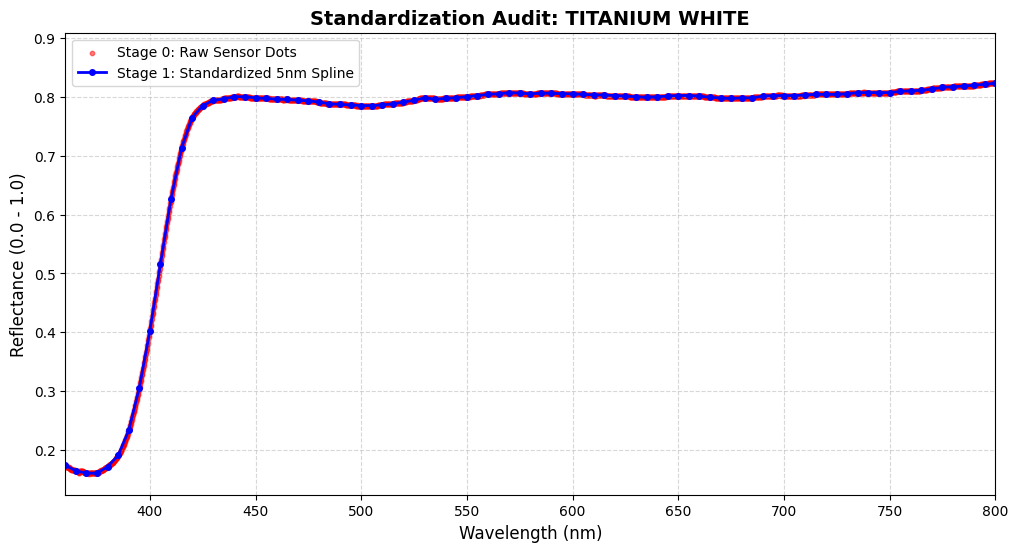

In [9]:
import matplotlib.pyplot as plt

def visualize_standardization_quality(stage0_list, stage1_list, pigment_name="titanium white"):
    """
    PURPOSE: Overlays Raw (Stage 0) vs Standardized (Stage 1) to check for data loss.
    SCIENCE: The Stage 1 curve should be a smooth, continuous line that 
             passes exactly through the Stage 0 'dots'.
    """
    # 1. Find the pigment in both datasets
    p0 = next((p for p in stage0_list if pigment_name in p['name'].lower()), None)
    p1 = next((p for p in stage1_list if pigment_name in p['name'].lower()), None)
    
    if not p0 or not p1:
        print(f"❌ Pigment '{pigment_name}' not found. Check spelling!")
        return

    # 2. Extract arrays
    w0, r0 = np.array(p0['wavelengths']), np.array(p0['reflectance']) / 100.0
    w1, r1 = np.array(p1['wavelengths']), np.array(p1['reflectance'])

    # 3. Create the Plot
    plt.figure(figsize=(12, 6))
    
    # Plot the original sensor data as dots (The 'Truth')
    plt.scatter(w0, r0, color='red', s=10, alpha=0.5, label='Stage 0: Raw Sensor Dots')
    
    # Plot our new standardized 5nm grid as a solid line (The 'Model')
    plt.plot(w1, r1, color='blue', linewidth=2, label='Stage 1: Standardized 5nm Spline', marker='o', markersize=4)

    # Formatting
    plt.title(f"Standardization Audit: {p1['name'].upper()}", fontsize=14, fontweight='bold')
    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Reflectance (0.0 - 1.0)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    # Zoom in on a specific part to see the 'Smoothness'
    plt.xlim(360, 800) 
    
    plt.show()

# --- RUN THE AUDIT ---
# Using 'titanium white' as it usually has the most complex curves
visualize_standardization_quality(stage0_data, stage1_data, "titanium white")


In [10]:
import json
import numpy as np
import colour
import os

# Paths
INPUT_JSON = './spectral_pipeline_output/stage1_standardized_data.json'
OUTPUT_DIR = './spectral_pipeline_output'

def stage2_calibrate_library(input_path, output_path, target_y=95.0):
    """
    PURPOSE: Calibrates the library so White looks like Artist-Grade White.
    SCIENCE: Uses CIE 1931 Luminance (Y) to find the 'Master Scale Factor'.
    """
    with open(input_path, 'r') as f:
        library = json.load(f)
    
    # 1. Setup CIE 1931 Environment
    # Standard Observer (The Human Eye) and D65 (Daylight)
    cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
    illuminant = colour.SDS_ILLUMINANTS['D65']
    
    # 2. Find the Anchor: Titanium White
    # We look for 'titanium white' in the name
    white_entry = next((p for p in library if "titanium white" in p['name'].lower()), None)
    
    if not white_entry:
        print("❌ Error: 'titanium white' not found in Stage 1 JSON. Calibration failed.")
        return
    
    # 3. Calculate current Luminance (Y) of the White
    w_wavelengths = np.array(white_entry['wavelengths'])
    w_reflectance = np.array(white_entry['reflectance'])
    
    sd_white = colour.SpectralDistribution(dict(zip(w_wavelengths, w_reflectance)))
    # We must align the CMFs to our 5nm grid for the math to work
    xyz_white = colour.sd_to_XYZ(sd_white, cmfs, illuminant, method='Integration')
    
    current_y = xyz_white[1] # XYZ index 1 is 'Y' (Luminance)
    
    # 4. Calculate the 'Master Scale Factor'
    scale_factor = target_y / current_y
    print(f"📊 Titanium White current Y: {round(current_y, 2)}")
    print(f"🚀 Calibration Factor: {round(scale_factor, 3)}x")

    # 5. Apply the Scale Factor to EVERY pigment in the library
    calibrated_library = []
    for p in library:
        refl_calibrated = np.array(p['reflectance']) * scale_factor
        # Safety Clip: Ensure no pigment reflects more than 100.1% light
        refl_calibrated = np.clip(refl_calibrated, 0.0, 1.0)
        
        p_calibrated = p.copy()
        p_calibrated['reflectance'] = refl_calibrated.tolist()
        # Store the scale factor used (good for debugging)
        p_calibrated['calibration_factor'] = scale_factor
        
        calibrated_library.append(p_calibrated)

    # 6. Save to Stage 2 JSON
    output_filename = os.path.join(output_path, "stage2_calibrated_data.json")
    with open(output_filename, 'w') as f:
        json.dump(calibrated_library, f, indent=4)
    
    print(f"✅ Stage 2 Complete: Library calibrated and saved to {output_filename}")
    return calibrated_library

# --- RUN ---
stage2_data = stage2_calibrate_library(INPUT_JSON, OUTPUT_DIR)


📊 Titanium White current Y: 79.92
🚀 Calibration Factor: 1.189x
✅ Stage 2 Complete: Library calibrated and saved to ./spectral_pipeline_output\stage2_calibrated_data.json


In [11]:
def test_stage2_calibration(data_list):
    white = next((p for p in data_list if "titanium white" in p['name'].lower()), None)
    
    # Re-calculate Y
    sd = colour.SpectralDistribution(dict(zip(white['wavelengths'], white['reflectance'])))
    cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
    illuminant = colour.SDS_ILLUMINANTS['D65']
    y_final = colour.sd_to_XYZ(sd, cmfs, illuminant, method='Integration')[1]
    
    print(f"🎯 Calibrated Titanium White Y: {round(y_final, 2)}")
    assert np.isclose(y_final, 95.0, atol=0.1)
    print("✅ Calibration is Perfect!")

test_stage2_calibration(stage2_data)


🎯 Calibrated Titanium White Y: 95.0
✅ Calibration is Perfect!


In [12]:
import json
import numpy as np
import os

# Paths
INPUT_JSON = './spectral_pipeline_output/stage2_calibrated_data.json'
OUTPUT_DIR = './spectral_pipeline_output'

def stage3_physics_transformation(input_path, output_path, concentration=30.0):
    """
    PURPOSE: Extracts 'Pure Pigment DNA' and simulates 'Infinite Thickness' (Masstone).
    SCIENCE: 
        1. Convert R to K/S (Absorption/Scattering ratio).
        2. Subtract the Acrylic Binder's absorption contribution.
        3. Simulate high concentration (Tube Paint) to remove White Card interference.
    """
    with open(input_path, 'r') as f:
        library = json.load(f)
    
    # 1. Isolate the Binder Reference
    binder_entry = next((p for p in library if "acrylic binder" in p['name'].lower()), None)
    if not binder_entry:
        print("❌ Error: 'NA_Acrylic_Binder' not found in Stage 2 JSON.")
        return

    # Convert Binder R to K/S (This is the 'noise' we want to remove)
    r_binder = np.array(binder_entry['reflectance'])
    ks_binder = ((1 - r_binder)**2) / (2 * r_binder + 1e-7)

    physics_library = []
    
    for p in library:
        # We don't process the binder itself as a pigment
        if "acrylic binder" in p['name'].lower():
            continue
            
        try:
            r_mix = np.array(p['reflectance'])
            
            # 2. CONVERT TO K/S (Total Absorption of Pigment + Binder + Card interference)
            ks_total = ((1 - r_mix)**2) / (2 * r_mix + 1e-7)
            
            # 3. SUBTRACT BINDER (Isolate the Pigment particles)
            # We assume a standard volume fraction where binder is the majority
            ks_pigment_only = np.maximum(ks_total - ks_binder, 0)
            
            # 4. SIMULATE MASSTONE (Infinite Thickness)
            # Multiplying by 'concentration' simulates the light traveling through 
            # so much pigment that it never sees the white card.
            ks_masstone = ks_pigment_only * concentration
            
            # 5. REVERSE K-M (Convert back to Reflectance)
            # Formula: R = 1 + K/S - sqrt( (K/S)^2 + 2*K/S )
            r_deep = 1 + ks_masstone - np.sqrt(ks_masstone**2 + 2 * ks_masstone)
            
            p_physics = p.copy()
            p_physics['reflectance'] = np.clip(r_deep, 0, 1).tolist()
            # We store the K/S 'DNA' for the future mixing engine!
            p_physics['ks_dna'] = ks_pigment_only.tolist()
            
            physics_library.append(p_physics)
            
        except Exception as e:
            print(f"⚠️ Physics error for {p['name']}: {e}")

    # 6. Save to Stage 3 JSON
    output_filename = os.path.join(output_path, "stage3_physics_data.json")
    with open(output_filename, 'w') as f:
        json.dump(physics_library, f, indent=4)
    
    print(f"✅ Stage 3 Complete: {len(physics_library)} pigments transformed to Masstone.")
    return physics_library

# --- RUN ---
stage3_data = stage3_physics_transformation(INPUT_JSON, OUTPUT_DIR)


✅ Stage 3 Complete: 81 pigments transformed to Masstone.


In [13]:
def test_stage3_physics(s2_list, s3_list, pigment_name="phthalo blue"):
    p2 = next((p for p in s2_list if pigment_name in p['name'].lower()), None)
    p3 = next((p for p in s3_list if pigment_name in p['name'].lower()), None)
    
    r2_avg = np.mean(p2['reflectance'])
    r3_avg = np.mean(p3['reflectance'])
    
    print(f"📊 {pigment_name.upper()} Reflectance Shift:")
    print(f"   Stage 2 (Pale/Acrylic): {round(r2_avg, 3)}")
    print(f"   Stage 3 (Deep/Oil):     {round(r3_avg, 3)}")
    
    assert r3_avg < r2_avg, "Physics failed to deepen the color!"
    print("✅ Stage 3 physics successfully removed the 'chalky' look.")

test_stage3_physics(stage2_data, stage3_data)


📊 PHTHALO BLUE Reflectance Shift:
   Stage 2 (Pale/Acrylic): 0.034
   Stage 3 (Deep/Oil):     0.001
✅ Stage 3 physics successfully removed the 'chalky' look.
